In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from src.diffeomorphisms.vector.poincare import PoincareVectorDiffeomorphism
from src.manifolds.hyperbolic.vector.standard import StandardVectorHyperbolic

# fix seed
torch.manual_seed(31)

### Construct data set ###

Data shape: torch.Size([2000, 3])


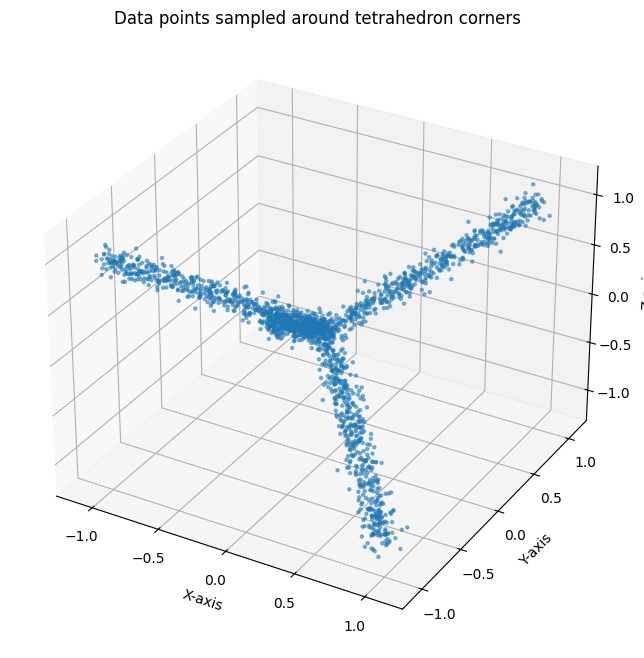

In [2]:
# construct data set from the four corners of a tetrahedron in R3
# construct tetrahedron corners
data_clusters = torch.tensor([[1.0, 1.0, 1.0],
                              [1.0, -1.0, -1.0],
                              [-1.0, 1.0, -1.0],
                              [-1.0, -1.0, 1.0]])

# generate data 
num_data_per_cluster = 500
data = []
for center in data_clusters:
    for _ in range(num_data_per_cluster):
        t = torch.rand(1)
        point = t * center + (1 - t) * torch.zeros(3)
        point += 0.05 * torch.randn(3)  # small Gaussian noise
        data.append(point)
data = torch.stack(data)
print("Data shape:", data.shape)

# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.5)
ax.set_title("Data points sampled around tetrahedron corners")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.show()

In [3]:
class RandomPairDataset(Dataset):
    def __init__(self, data):
        self.data = data            # shape: N x d
        self.N = data.shape[0]

    def __len__(self):
        return self.N  # you can pick another value if you wish

    def __getitem__(self, idx):
        # x: deterministic sample (makes training deterministic per epoch)
        x = self.data[idx]
        # x_prime: random sample, different from idx
        idx2 = torch.randint(0, self.N - 1, (1,)).item()
        if idx2 >= idx:
            idx2 += 1
        x_prime = self.data[idx2]
        return x, x_prime
    
# create dataset and dataloader
pair_dataset = RandomPairDataset(data)
dataloader = DataLoader(pair_dataset, batch_size=128, shuffle=True)

### Embed data set ###

In [ ]:
# construct Gromov-Monge Embedding in Hyperbolic Space
# construct neural network architecture
class SimpleNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = torch.nn.Linear(input_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = torch.nn.Linear(hidden_dim, output_dim)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x
    
# instantiate the neural network
input_dim = 3
hidden_dim = 20
output_dim = 2  # we will embed into 2D hyperbolic space
nn_model = SimpleNN(input_dim, hidden_dim, output_dim)

# construct Gromov-Monge Embedding with poincare map
class HyperbolicGromovMongeEmbedding(torch.nn.Module):
    def __init__(self, nn_model, output_dim=2):
        super(HyperbolicGromovMongeEmbedding, self).__init__()
        self.nn_model = nn_model
        self.poincare_map = PoincareVectorDiffeomorphism(output_dim)
        self.manifold = StandardVectorHyperbolic(output_dim)
        self.origin = None

    def forward(self, x):
        """
        
        :param x: N x d
        :return: N x output_dim
        """
        nn_output = self.nn_model(x)
        hyperbolic_embedding = self.poincare_map(nn_output)
        if self.origin is not None:
            hyperbolic_embedding = self.translate(hyperbolic_embedding, self.origin)
        return hyperbolic_embedding
    
    def set_origin(self, origin):
        """
        
        :param origin: output_dim 
        """
        self.origin = origin

    def translate(self, z, translation):
        """
        
        :param z: N x output_dim
        :param translation: output_dim
        :return: N x output_dim
        """
        norm_tr_sq = torch.sum(translation**2)
        norm_x_sq = torch.sum(z**2, dim=-1)
        xtr_dot = torch.sum(z * translation.unsqueeze(0), dim=-1)
        numerator = (1 - norm_tr_sq) * z - (1 - 2 * xtr_dot.unsqueeze(-1) + norm_x_sq.unsqueeze(-1)) * translation.unsqueeze(0)
        denominator = 1 - 2 * xtr_dot + norm_tr_sq * norm_x_sq
        return numerator / denominator.unsqueeze(-1)

    def distance(self, x1, x2):
        """
        
        :param x1: N x d
        :param x2: N x d
        :return: N
        """
        emb1 = self.forward(x1)
        emb2 = self.forward(x2)
        dist = self.manifold.distance(emb1.unsqueeze(1), emb2.unsqueeze(1)).squeeze(2).squeeze(1)
        return dist
    
    def interpolate(self, x1, x2, t):
        """
        
        :param x1: N x d
        :param x2: N x d
        :param t: K
        :return: N x K x output_dim
        """
        emb1 = self.forward(x1)
        emb2 = self.forward(x2)
        interp_emb = self.manifold.geodesic(emb1.unsqueeze(1), emb2.unsqueeze(1), t).squeeze(2).squeeze(1)
        return interp_emb
    
    def barycentre(self, x):
        """
        
        :param x: N x d
        :return: output_dim
        """
        emb_points = self.forward(x)
        barycentre = self.manifold.barycentre(emb_points)
        return barycentre

# instantiate Gromov-Monge Embedding
T = HyperbolicGromovMongeEmbedding(nn_model, output_dim=2)

In [5]:
# construct train loop
optimizer = torch.optim.Adam(T.nn_model.parameters(), lr=0.001)
num_epochs = 50
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for x, x_prime in dataloader:
        optimizer.zero_grad()
        dist_data = torch.norm(x - x_prime, dim=1)
        dist_emb = T.distance(x, x_prime)
        loss = torch.log((1 + dist_emb ** 2) / (1 + dist_data ** 2)).pow(2).mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)
    epoch_loss /= len(pair_dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.6f}")


Epoch 1/50, Loss: 1.107273
Epoch 2/50, Loss: 0.752215
Epoch 3/50, Loss: 0.345244
Epoch 4/50, Loss: 0.165422
Epoch 5/50, Loss: 0.143872
Epoch 6/50, Loss: 0.129077
Epoch 7/50, Loss: 0.099330
Epoch 8/50, Loss: 0.059735
Epoch 9/50, Loss: 0.029030
Epoch 10/50, Loss: 0.020816
Epoch 11/50, Loss: 0.019457
Epoch 12/50, Loss: 0.019209
Epoch 13/50, Loss: 0.018099
Epoch 14/50, Loss: 0.017593
Epoch 15/50, Loss: 0.017718
Epoch 16/50, Loss: 0.016885
Epoch 17/50, Loss: 0.017527
Epoch 18/50, Loss: 0.016676
Epoch 19/50, Loss: 0.017826
Epoch 20/50, Loss: 0.016732
Epoch 21/50, Loss: 0.018025
Epoch 22/50, Loss: 0.016298
Epoch 23/50, Loss: 0.017672
Epoch 24/50, Loss: 0.017871
Epoch 25/50, Loss: 0.017796
Epoch 26/50, Loss: 0.016530
Epoch 27/50, Loss: 0.016891
Epoch 28/50, Loss: 0.017552
Epoch 29/50, Loss: 0.017316
Epoch 30/50, Loss: 0.016688
Epoch 31/50, Loss: 0.016130
Epoch 32/50, Loss: 0.016876
Epoch 33/50, Loss: 0.017156
Epoch 34/50, Loss: 0.017912
Epoch 35/50, Loss: 0.016943
Epoch 36/50, Loss: 0.016601
E

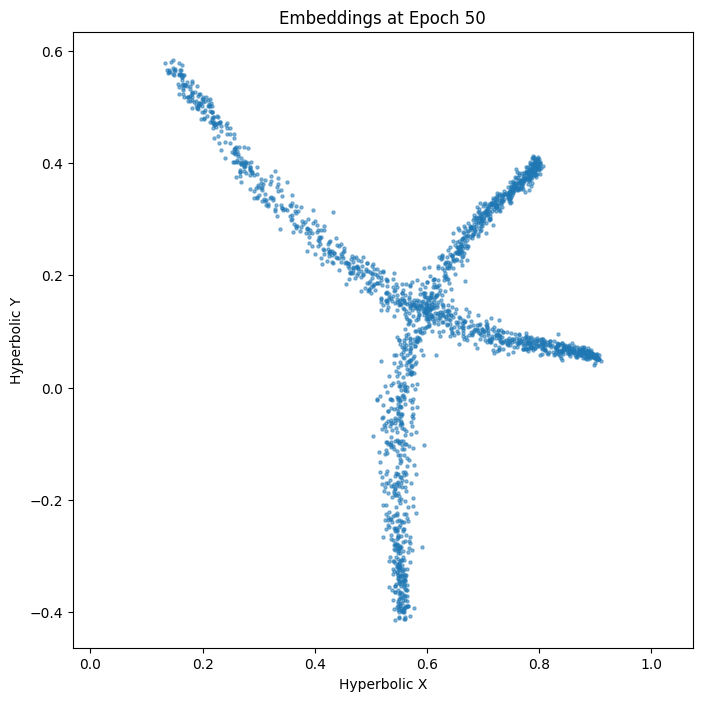

In [6]:
# visualize embeddings
with torch.no_grad():
    embeddings = T(data).cpu().numpy()
plt.figure(figsize=(8, 8))
plt.scatter(embeddings[:, 0], embeddings[:, 1], s=5, alpha=0.5)
plt.title(f"Embeddings at Epoch {epoch+1}")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.show()

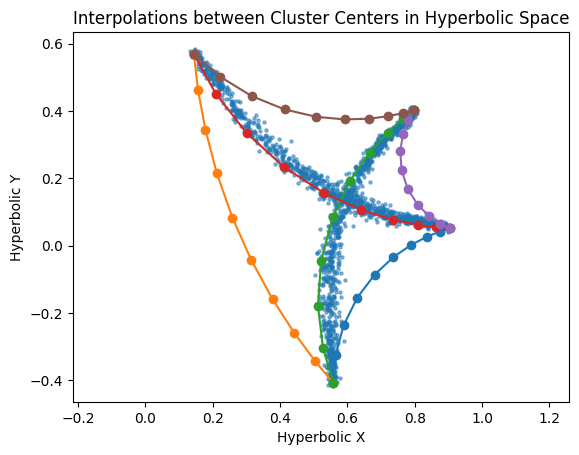

In [7]:
# interpolate between cluster centers
plt.scatter(embeddings[:, 0], embeddings[:, 1], s=5, alpha=0.5)
for i in range(data_clusters.shape[0]):
    for j in range(i + 1, data_clusters.shape[0]):
        center1 = data_clusters[i].unsqueeze(0)
        center2 = data_clusters[j].unsqueeze(0)
        t_values = torch.linspace(0, 1, steps=10)
        with torch.no_grad():
            interp_points = T.interpolate(center1, center2, t_values)[0]
        # interp_points = interp_points.cpu().numpy()
        plt.plot(interp_points[:, 0], interp_points[:, 1], marker='o')
plt.title("Interpolations between Cluster Centers in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.show()

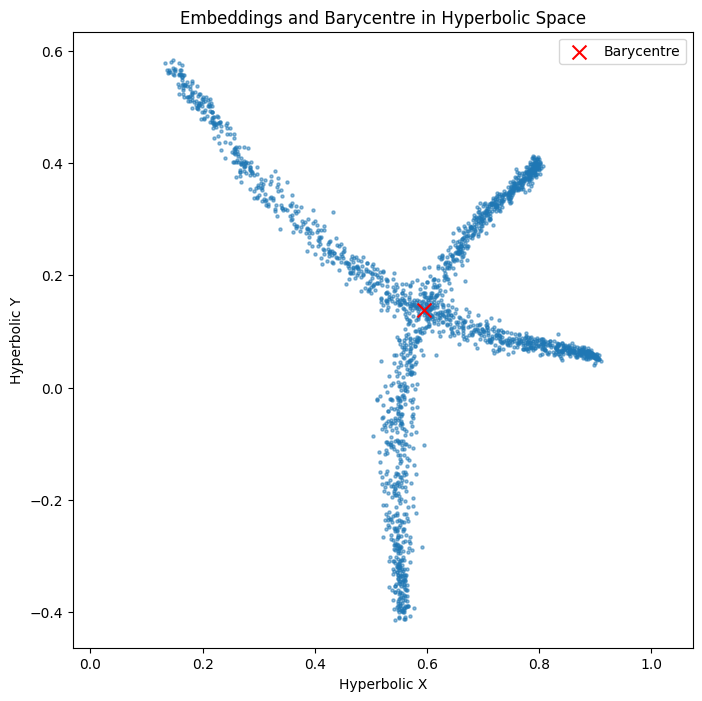

In [8]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    barycentre = T.barycentre(data)

plt.figure(figsize=(8, 8))
plt.scatter(embeddings[:, 0], embeddings[:, 1], s=5, alpha=0.5)
plt.scatter(barycentre[0].item(), barycentre[1].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.show()  

In [9]:
# translate origin with isometr
# check that distances are preserved I: compute old distances
with torch.no_grad():
    dist_emb = T.distance(data_clusters[1:], data_clusters[:-1])

# update origin
T.set_origin(barycentre)

# check that distances are preserved II: compute new distances
with torch.no_grad():
    dist_emb_centered = T.distance(data_clusters[1:], data_clusters[:-1])

print("Pairwise distance matrix in embedding space between cluster centers:")
print((dist_emb - dist_emb_centered).abs().max())  # should be close to zero

Pairwise distance matrix in embedding space between cluster centers:
tensor(1.9073e-06)


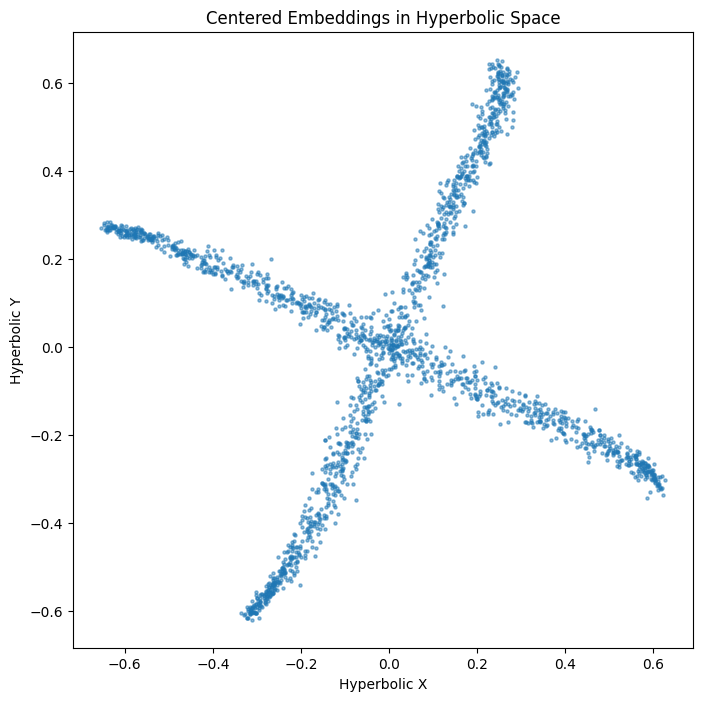

In [10]:
# compute embeddings again after centering
with torch.no_grad():
    embeddings_centered = T(data)
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5)
plt.title("Centered Embeddings in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.show()

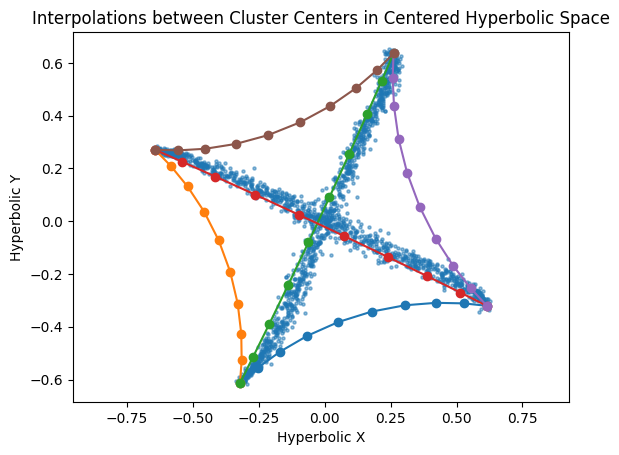

In [11]:
# interpolate between cluster centers after centering
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5)
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        center1 = data_clusters[i].unsqueeze(0)
        center2 = data_clusters[j].unsqueeze(0)
        t_values = torch.linspace(0, 1, steps=10)
        with torch.no_grad():
            interp_points_centered = T.interpolate(center1, center2, t_values)[0]
        plt.plot(interp_points_centered[:, 0], interp_points_centered[:, 1], marker='o')
plt.title("Interpolations between Cluster Centers in Centered Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.show()

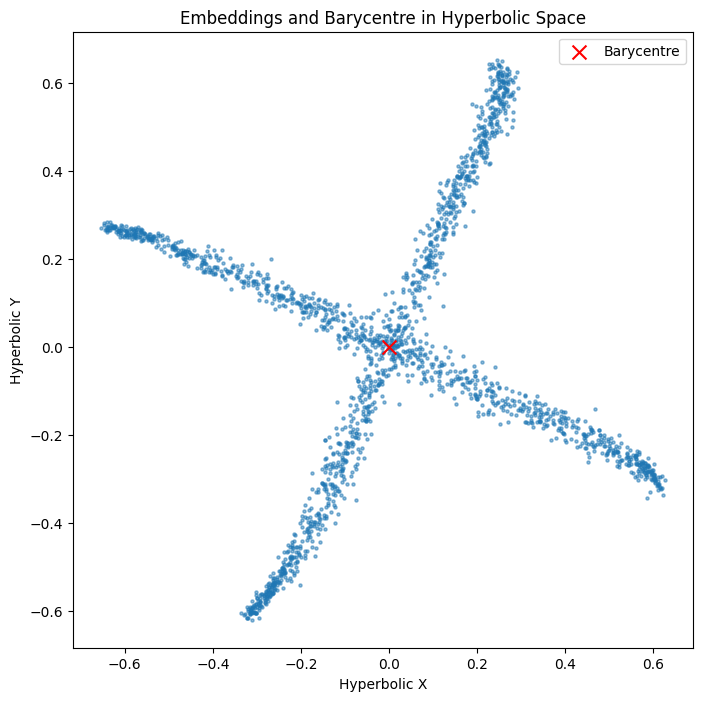

Distance between barycentres before and after centering:
2.437876901240088e-06


In [14]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    barycentre_centered = T.barycentre(data)

plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5)
plt.scatter(barycentre_centered[0].item(), barycentre_centered[1].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.show()  

# check difference between barycentres
print("Distance between barycentres before and after centering:")
translated_barycentre = T.translate(barycentre, barycentre)
print((translated_barycentre - barycentre_centered).norm().item())  # should be close to zero

### Learn embedding-informed pullback geometry ###